# Credit Card Approval

## Importing libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

## Load data

data source: https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction

In [2]:
application_details = pd.read_csv('Datasets/application_record.csv')
credit_record = pd.read_csv('Datasets/credit_record.csv')

### Merge By ID

In [3]:
df = application_details.merge(credit_record, how='inner', on=['ID'])

## Check dimensions 

In [4]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [5]:
df.shape

(777715, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  object 
 2   FLAG_OWN_CAR         777715 non-null  object 
 3   FLAG_OWN_REALTY      777715 non-null  object 
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  object 
 7   NAME_EDUCATION_TYPE  777715 non-null  object 
 8   NAME_FAMILY_STATUS   777715 non-null  object 
 9   NAME_HOUSING_TYPE    777715 non-null  object 
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  int64  
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 15  FLAG_EMAIL       

In [7]:
df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        240048
CNT_FAM_MEMBERS             0
MONTHS_BALANCE              0
STATUS                      0
dtype: int64

## Data Exploration & Visualization

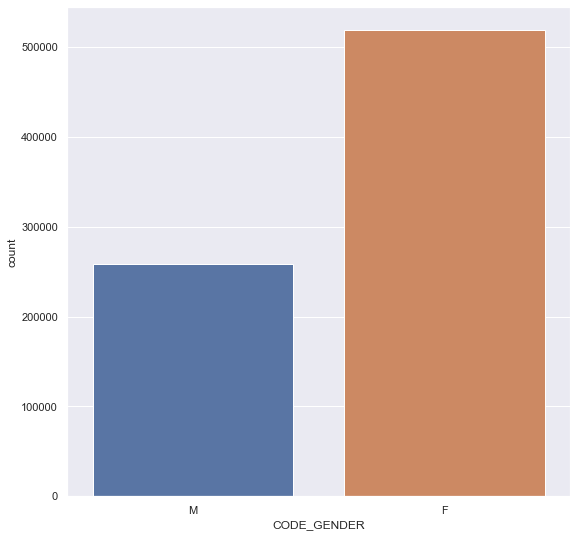

In [8]:
plt.figure(figsize=(9, 9))
sns.countplot(x= 'CODE_GENDER', data=df)
plt.show()

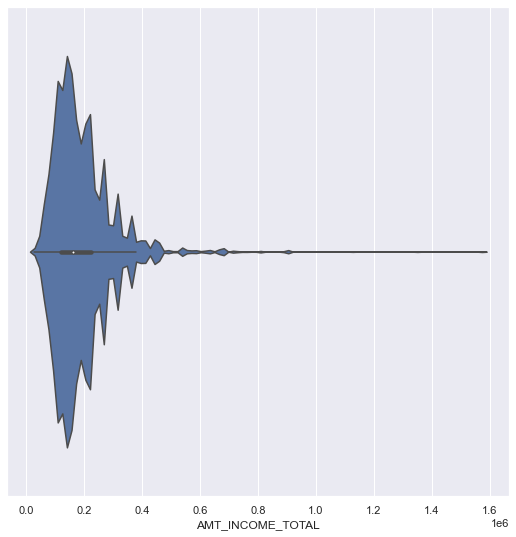

In [9]:
plt.figure(figsize=(9, 9))
sns.violinplot(x= 'AMT_INCOME_TOTAL', data=df)
plt.show()

In [10]:
df.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [16]:
df = pd.concat([df, pd.get_dummies(df['CODE_GENDER'], prefix='gENDER', drop_first=True)], axis=1)

In [19]:
df.sample(20)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,gENDER_M
500426,5096201,F,N,N,0,202500.0,Pensioner,Secondary / secondary special,Married,House / apartment,...,365243,1,0,1,0,NaN,2.0,-11,0,0
622063,5117283,M,Y,Y,1,180000.0,Working,Higher education,Married,House / apartment,...,-1800,1,0,0,0,Managers,3.0,-24,C,1
701721,5140178,F,N,Y,0,99000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-2410,1,0,0,0,NaN,1.0,-28,X,0
723311,5143244,F,N,N,0,135000.0,State servant,Higher education,Separated,With parents,...,-1991,1,1,0,0,IT staff,1.0,-20,C,0
598434,5115860,F,Y,Y,1,315000.0,Working,Secondary / secondary special,Married,House / apartment,...,-6099,1,0,0,0,Laborers,3.0,-8,C,0
35278,5010893,F,N,Y,0,157500.0,Pensioner,Secondary / secondary special,Married,House / apartment,...,365243,1,0,0,1,NaN,2.0,-27,X,0
513969,5097189,F,N,Y,0,130500.0,Pensioner,Secondary / secondary special,Widow,House / apartment,...,365243,1,0,1,0,NaN,1.0,-4,C,0
640833,5125191,M,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,...,-4152,1,1,0,0,NaN,2.0,-2,C,1
74433,5023232,F,Y,Y,0,225000.0,Commercial associate,Higher education,Single / not married,House / apartment,...,-1270,1,1,0,0,Core staff,1.0,-4,C,0
632355,5118157,F,N,N,1,202500.0,Working,Higher education,Married,House / apartment,...,-2014,1,1,0,0,NaN,3.0,-3,0,0


<AxesSubplot:>

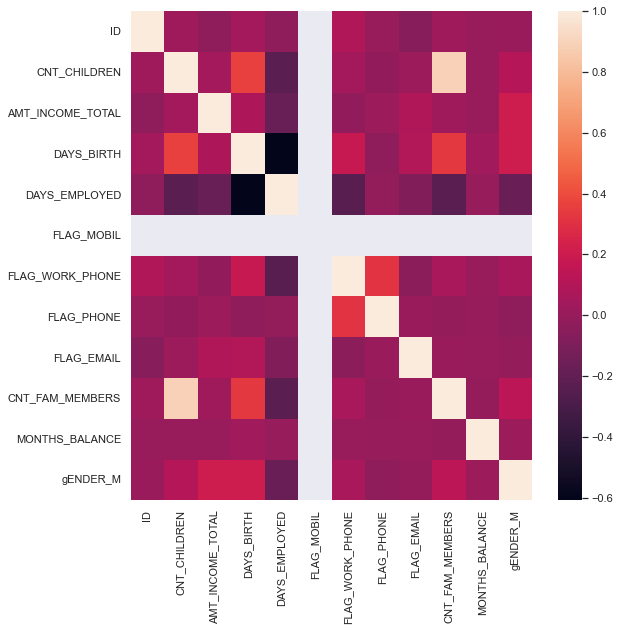

In [21]:
plt.figure(figsize=(9,9))
sns.heatmap(df.corr())

<AxesSubplot:xlabel='CNT_CHILDREN', ylabel='Density'>

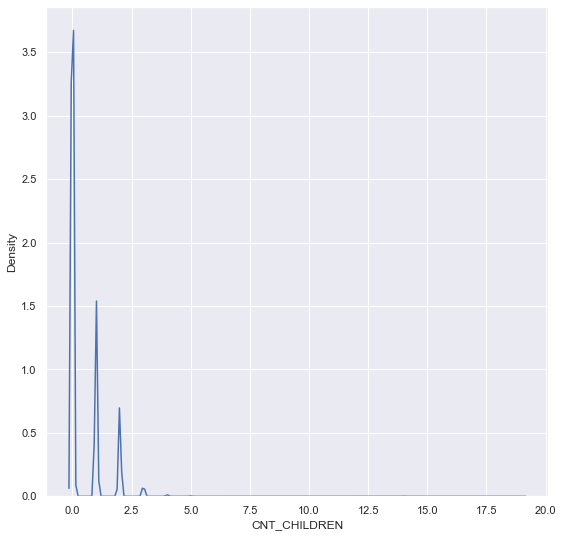

In [34]:
plt.figure(figsize=(9,9))
sns.kdeplot(x=df['CNT_CHILDREN'], data=df)

<AxesSubplot:xlabel='CNT_CHILDREN', ylabel='Count'>

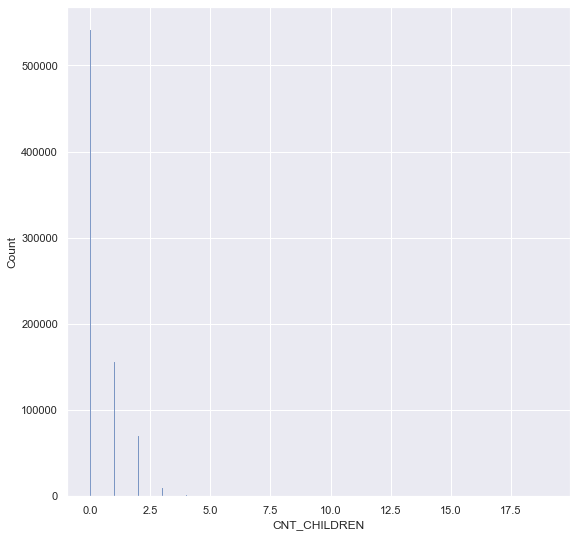

In [33]:
plt.figure(figsize=(9,9))
sns.histplot(x=df['CNT_CHILDREN'], data=df)